In [3]:
import os, pickle, torch, torch.nn as nn 
from torchvision import models, transforms 
from torch.utils.data import DataLoader, Dataset 
from PIL import Image 
from tqdm import tqdm 

def find_image_dir(): 
    # Common Kaggle root 
    base_input = '/kaggle/input' 
    
    # Walk through the input directory to find where the images actually are 
    for root, dirs, files in os.walk(base_input): 
        # Look for the folder containing a high volume of jpg files 
        if len([f for f in files if f.endswith('.jpg')]) > 1000: 
            return root 
    return None 

IMAGE_DIR = find_image_dir() 
OUTPUT_FILE = 'flickr30k_features.pkl' 

if IMAGE_DIR: 
    print(f" Found images at: {IMAGE_DIR}") 
else: 
    raise FileNotFoundError("Could not find the Flickr30k image directory. Please ensure the dataset is added to the notebook.") 

# --- THE DATASET CLASS --- 
class FlickrDataset(Dataset): 
    def __init__(self, img_dir, transform): 
        self.img_names = [f for f in os.listdir(img_dir) if f.endswith(('.jpg', '.jpeg'))] 
        self.transform = transform 
        self.img_dir = img_dir 
        
    def __len__(self):  
        return len(self.img_names) 
        
    def __getitem__(self, idx): 
        name = self.img_names[idx] 
        img_path = os.path.join(self.img_dir, name) 
        img = Image.open(img_path).convert('RGB') 
        return self.transform(img), name 

# --- REMAINDER OF THE PIPELINE (AS BEFORE) --- 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") 
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT) 
model = nn.Sequential(*list(model.children())[:-1]) # Feature vector only 
model = nn.DataParallel(model).to(device) 
model.eval() 

transform = transforms.Compose([ 
    transforms.Resize((224, 224)), 
    transforms.ToTensor(), 
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)) 
]) 
 
dataset = FlickrDataset(IMAGE_DIR, transform) 
loader = DataLoader(dataset, batch_size=128, num_workers=4) 
features_dict = {} 
 
with torch.no_grad(): 
    for imgs, names in tqdm(loader, desc="Extracting Features"): 
        feats = model(imgs.to(device)).view(imgs.size(0), -1) 
        for i, name in enumerate(names): 
            features_dict[name] = feats[i].cpu().numpy() 
 
with open(OUTPUT_FILE, 'wb') as f: 
    pickle.dump(features_dict, f) 
 
print(f"Success! {len(features_dict)} images processed and saved to {OUTPUT_FILE}")

 Found images at: /kaggle/input/datasets/adityajn105/flickr30k/Images
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 171MB/s] 
Extracting Features: 100%|██████████| 249/249 [01:48<00:00,  2.30it/s]


Success! 31783 images processed and saved to flickr30k_features.pkl


In [4]:
import pandas as pd
import re
from collections import Counter

class Vocabulary:
    def __init__(self, freq_threshold=5):
        # Action: Define the special tokens
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.freq_threshold = freq_threshold

    def __len__(self):
        return len(self.itos)

    @staticmethod
    def tokenize(text):
        # Action: Clean the text (lowercase and remove punctuation)
        text = str(text).lower()
        text = re.sub(r'[^a-z0-9\s]', '', text)
        return text.split()

    def build_vocabulary(self, sentence_list):
        # Action: Count all words in the dataset
        frequencies = Counter()
        idx = 4 # Start assigning numbers after our 4 special tokens

        for sentence in sentence_list:
            for word in self.tokenize(sentence):
                frequencies[word] += 1

                # Action: Only add words that appear frequently enough
                if frequencies[word] == self.freq_threshold:
                    self.stoi[word] = idx
                    self.itos[idx] = word
                    idx += 1

    def numericalize(self, text):
        tokenized = self.tokenize(text)
        return [self.stoi["<SOS>"]] + \
               [self.stoi.get(token, self.stoi["<UNK>"]) for token in tokenized] + \
               [self.stoi["<EOS>"]]

# --- EXECUTION ---

# 1. Load the captions.txt file (using the path from Part 1)
file_path = '/kaggle/input/datasets/adityajn105/flickr30k/captions.txt'
df = pd.read_csv(file_path, delimiter=',')
print("Columns: ", df.columns)
# 2. Extract just the text column (usually named ' caption' or 'caption' in this dataset)
# Note: Flickr30k sometimes has a leading space in the column name, hence ' caption'
captions = df['caption'].tolist() 

# 3. Initialize and build the vocabulary
vocab = Vocabulary(freq_threshold=5)
vocab.build_vocabulary(captions)

print(f"Total unique words in vocabulary: {len(vocab)}")

# 4. Test it on the very first caption
sample_caption = captions[0]
numerical_version = vocab.numericalize(sample_caption)

print(f"Original: {sample_caption}")
print(f"Numericalized: {numerical_version}")

Columns:  Index(['image', 'caption'], dtype='object')
Total unique words in vocabulary: 7727
Original:  Two young guys with shaggy hair look at their hands while hanging out in the yard .
Numericalized: [1, 6, 22, 155, 25, 2107, 77, 153, 24, 57, 253, 20, 459, 101, 4, 12, 357, 2]


In [5]:
import torch
import torch.nn as nn

class EncoderCNN(nn.Module):
    def __init__(self, hidden_size=512):
        super(EncoderCNN, self).__init__()
        
        # Action: Create the mathematical bridge from 2048 to 512
        self.linear = nn.Linear(2048, hidden_size)
        
        # Action: Add an activation function
        self.relu = nn.ReLU()
        
    def forward(self, cached_features):
        # Input shape: [batch_size, 2048]
        
        # Project the features down to the hidden_size
        projected_features = self.linear(cached_features)
        
        # Apply the activation function
        final_features = self.relu(projected_features)
        
        # Output shape: [batch_size, 512]
        return final_features

In [6]:
import torch
import torch.nn as nn

class DecoderRNN(nn.Module):
    def __init__(self, embed_size, hidden_size, vocab_size, num_layers):
        super(DecoderRNN, self).__init__()
        # If embed_size is 512, then self.embed outputs 512-D vectors
        self.embed = nn.Embedding(vocab_size, embed_size)
        
        # The LSTM input_size MUST match the concatenated dimension (512)
        self.lstm = nn.LSTM(embed_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, vocab_size)

    def forward(self, features, captions):
        # 1. Remove <EOS> from the end of the caption for input
        captions = captions[:, :-1]
        
        # 2. THE FIX: Use self.embed, NOT self.decoder.embed
        embeddings = self.embed(captions) 
        
        # 3. Combine image features (as the first word) with the word embeddings
        # Dim: [batch, sequence, embed_size]
        inputs = torch.cat((features.unsqueeze(1), embeddings), dim=1)
        
        # 4. Pass through LSTM
        hiddens, _ = self.lstm(inputs)
        
        # 5. Final linear layer to get word probabilities
        outputs = self.linear(hiddens)
        return outputs

In [7]:
import torch.nn as nn

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, features, captions):
        # Pass raw image features (2048-D) through Encoder to get (512-D)
        encoded_features = self.encoder(features)
        
        # Pass (512-D) features and text to the Decoder
        outputs = self.decoder(encoded_features, captions)
        return outputs

In [8]:
import pickle
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import random_split, DataLoader, Dataset

# 1. Define the missing Dataset class to pair features with captions
class FeatureDataset(Dataset):
    def __init__(self, features_dict, df, vocab):
        self.features_dict = features_dict
        self.df = df
        self.vocab = vocab
        self.image_names = df['image'].tolist()
        self.captions = df['caption'].tolist()

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_name = self.image_names[idx]
        caption = self.captions[idx]
        
        # Get the pre-extracted feature
        feature = torch.tensor(self.features_dict[image_name], dtype=torch.float32)
        
        # Convert caption to numbers
        tokens = torch.tensor(self.vocab.numericalize(caption), dtype=torch.long)
        
        return feature, tokens

# 2. Define the missing Collate function to handle variable-length sequences
class CapsCollate:
    def __init__(self, pad_idx):
        self.pad_idx = pad_idx

    def __call__(self, batch):
        # Stack features
        features = [item[0] for item in batch]
        features = torch.stack(features, dim=0)
        
        # Pad target captions
        targets = [item[1] for item in batch]
        targets = pad_sequence(targets, batch_first=True, padding_value=self.pad_idx)
        
        return features, targets

# --- EXECUTION ---

# 1. Load the saved features_dict from Cell 1
with open('flickr30k_features.pkl', 'rb') as f:
    features_dict = pickle.load(f)

# 2. Instantiate the dataset using the loaded dictionary
full_dataset = FeatureDataset(features_dict, df, vocab)

# 3. Initialize the Collate function with your specific <PAD> number
pad_idx = vocab.stoi["<PAD>"]
collate_fn = CapsCollate(pad_idx=pad_idx)

# 4. Split dataset
total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size = total_size - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, collate_fn=collate_fn)

print(f"Dataloaders ready! Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

Dataloaders ready! Train batches: 1987, Val batches: 497


In [9]:
import torch.optim as optim
import torch.nn as nn

vocab_size = len(vocab)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Re-initialize model to ensure it matches the current vocab_size
encoder = EncoderCNN(hidden_size=512).to(device)
decoder = DecoderRNN(embed_size=512, hidden_size=512, vocab_size=vocab_size, num_layers=1).to(device)
model = Seq2Seq(encoder, decoder).to(device)

num_epochs = 4
pad_idx = vocab.stoi["<PAD>"]
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Action: Track the best validation score. Initialize it to infinity.
best_val_loss = float('inf') 
checkpoint_path = 'best_flickr30k_model.pth'

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    
    # ========================
    # PHASE 1: TRAINING
    # ========================
    model.train() # Action: Turns ON Dropout and Gradient Tracking
    total_train_loss = 0
    
    for features, captions in train_loader:
        features, captions = features.to(device), captions.to(device)

        optimizer.zero_grad()
        outputs = model(features, captions)
        
        # 1. Align Outputs: Skip the very first prediction (the one made for the image)
        # This reduces the sequence length by 1.
        outputs = outputs[:, 1:, :].reshape(-1, vocab_size) 
        
        # 2. Align Targets: Skip the <SOS> token so the model is always 
        # trying to predict the NEXT word.
        targets = captions[:, 1:].reshape(-1) 
        
        # Now both will have a batch size of 2240 (for batch_size 64)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        total_train_loss += loss.item()
        
    avg_train_loss = total_train_loss / len(train_loader)

    train_losses.append(avg_train_loss)
    # ========================
    # PHASE 2: VALIDATION
    # ========================
    model.eval() # Action: Turns OFF training behaviors
    total_val_loss = 0
    
    with torch.no_grad(): # Action: Completely disables memory-heavy gradient tracking
        for features, captions in val_loader:
            features, captions = features.to(device), captions.to(device)

            # Note: No optimizer.zero_grad(), no backward(), no step()
            # --- TRAINING BLOCK FIX ---
            outputs = model(features, captions)
            
            # 1. Slice outputs to skip the 'image' prediction step
            # This makes the sequence length match captions[:, 1:]
            outputs = outputs[:, 1:, :].reshape(-1, vocab_size) 
            
            # 2. Slice targets to skip the <SOS> token
            targets = captions[:, 1:].reshape(-1) 
    
            loss = criterion(outputs, targets)
            total_val_loss += loss.item()
            
    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    
    # ========================
    # METRICS OUTPUT
    # ========================
    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Loss: {avg_train_loss:.4f} | Validation Loss: {avg_val_loss:.4f}")

    # Action: Check if this epoch was the best one yet
    if avg_val_loss < best_val_loss:
        print(f"--> Validation loss improved from {best_val_loss:.4f} to {avg_val_loss:.4f}. Saving model!")
        
        # 1. Update the record
        best_val_loss = avg_val_loss
        
        # 2. Save the math (state_dict) to the Kaggle working directory
        torch.save(model.state_dict(), checkpoint_path)

Epoch [1/4] | Train Loss: 3.6169 | Validation Loss: 3.1802
--> Validation loss improved from inf to 3.1802. Saving model!
Epoch [2/4] | Train Loss: 2.9728 | Validation Loss: 2.9671
--> Validation loss improved from 3.1802 to 2.9671. Saving model!
Epoch [3/4] | Train Loss: 2.7063 | Validation Loss: 2.8869
--> Validation loss improved from 2.9671 to 2.8869. Saving model!
Epoch [4/4] | Train Loss: 2.5117 | Validation Loss: 2.8674
--> Validation loss improved from 2.8869 to 2.8674. Saving model!


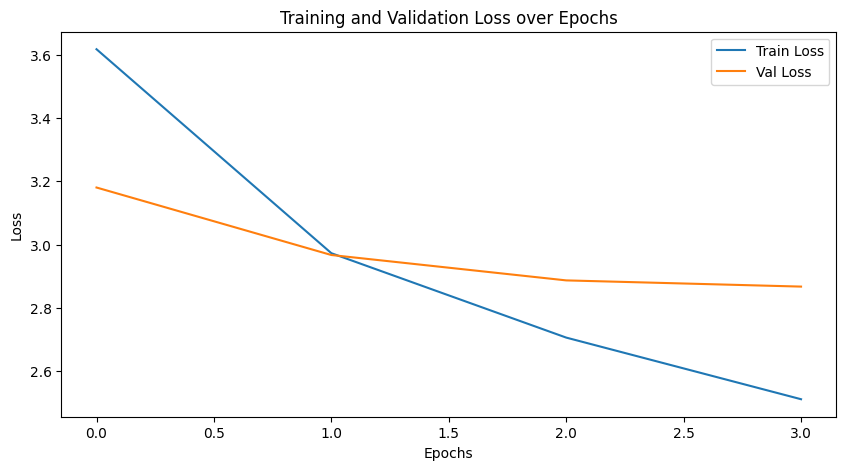

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
from nltk.translate.bleu_score import corpus_bleu

def evaluate_bleu(model, dataloader, vocab):
    model.eval()
    references = []
    candidates = []
    
    with torch.no_grad():
        for features, captions in tqdm(dataloader, desc="Calculating BLEU"):
            features = features.to(device)
            for i in range(features.size(0)):
                # 1. Get Ground Truth
                img_feat = model.encoder(features[i].unsqueeze(0))
                # 2. Get Prediction
                pred = beam_search(model, img_feat.squeeze(0), vocab)
                
                # 3. Clean and Tokenize for NLTK
                ref = [vocab.itos[idx] for idx in captions[i].tolist() 
                       if vocab.itos[idx] not in ["<PAD>", "<SOS>", "<EOS>"]]
                
                references.append([ref])
                candidates.append(pred.split())

    score = corpus_bleu(references, candidates)
    print(f"\nFinal BLEU-4 Score: {score*100:.2f}")

evaluate_bleu(model, val_loader, vocab)

In [14]:
import pickle
with open('vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)
print("Vocabulary saved!")

Vocabulary saved!


In [15]:
from IPython.display import FileLink

display(FileLink('flickr30k_features.pkl'))

# Generate a link for your model weights
display(FileLink('best_flickr30k_model.pth'))

# Generate a link for your vocabulary
display(FileLink('vocab.pkl'))

/kaggle/working/flickr30k_features.pkl

/kaggle/working/best_flickr30k_model.pth

/kaggle/working/vocab.pkl

In [12]:
def beam_search(model, feature, vocab, beam_width=3, max_len=20):
    model.eval()
    # Move raw 2048-D feature through the linear encoder layer to get 512-D
    # feature = model.encoder(raw_feature.to(device))
    
    # 1. Initialize with the image feature and <SOS> token
    start_token = vocab.stoi["<SOS>"]
    # (sequence, score, hidden_state)
    sequences = [([start_token], 0.0, None)] 
    
    for _ in range(max_len):
        all_candidates = []
        for seq, score, h_state in sequences:
            if seq[-1] == vocab.stoi["<EOS>"]:
                all_candidates.append((seq, score, h_state))
                continue
            
            # Predict next word
            inputs = torch.tensor([seq[-1]]).to(device)
            embeds = model.decoder.embed(inputs)
            
            # Handle the first step (image feature) vs subsequent steps
            # 1. Get the LSTM output and hidden state
            if h_state is None:
                # First step: initialize hidden state with image feature
                # feature shape is (512), we need (1, 1, 512)
                output, h_state = model.decoder.lstm(feature.view(1, 1, -1), None)
            else:
                # Subsequent steps: use word embedding
                output, h_state = model.decoder.lstm(embeds.view(1, 1, -1), h_state)
            
            # 2. Prepare logits
            # output is (1, 1, 512) -> squeeze(1) makes it (1, 512)
            logits = model.decoder.linear(output.squeeze(1)) 
            
            # 3. Calculate log_probs
            # Now dim=1 exists (it's the vocabulary dimension!)
            log_probs = torch.log_softmax(logits, dim=1)
            
            # Get top K candidates
            top_probs, top_indices = log_probs.topk(beam_width)
            for i in range(beam_width):
                candidate = (seq + [top_indices[0][i].item()], 
                             score + top_probs[0][i].item(), 
                             h_state)
                all_candidates.append(candidate)
        
        # Keep only the top 'beam_width' candidates
        ordered = sorted(all_candidates, key=lambda x: x[1], reverse=True)
        sequences = ordered[:beam_width]
        
        # If all top sequences ended with <EOS>, stop early
        if all(s[0][-1] == vocab.stoi["<EOS>"] for s in sequences):
            break

    # 2. Return the best sequence as a string
    best_seq = sequences[0][0]
    caption = [vocab.itos[i] for i in best_seq if vocab.itos[i] not in ["<SOS>", "<EOS>", "<PAD>"]]
    return " ".join(caption)

Image 1: red white and black dog jumping in the air
Image 2: a man in a white shirt and blue jeans is walking down the street
Image 3: a skier flies through the air
Image 4: a woman in a white tank top has her hand on her head
Image 5: a group of men in uniform


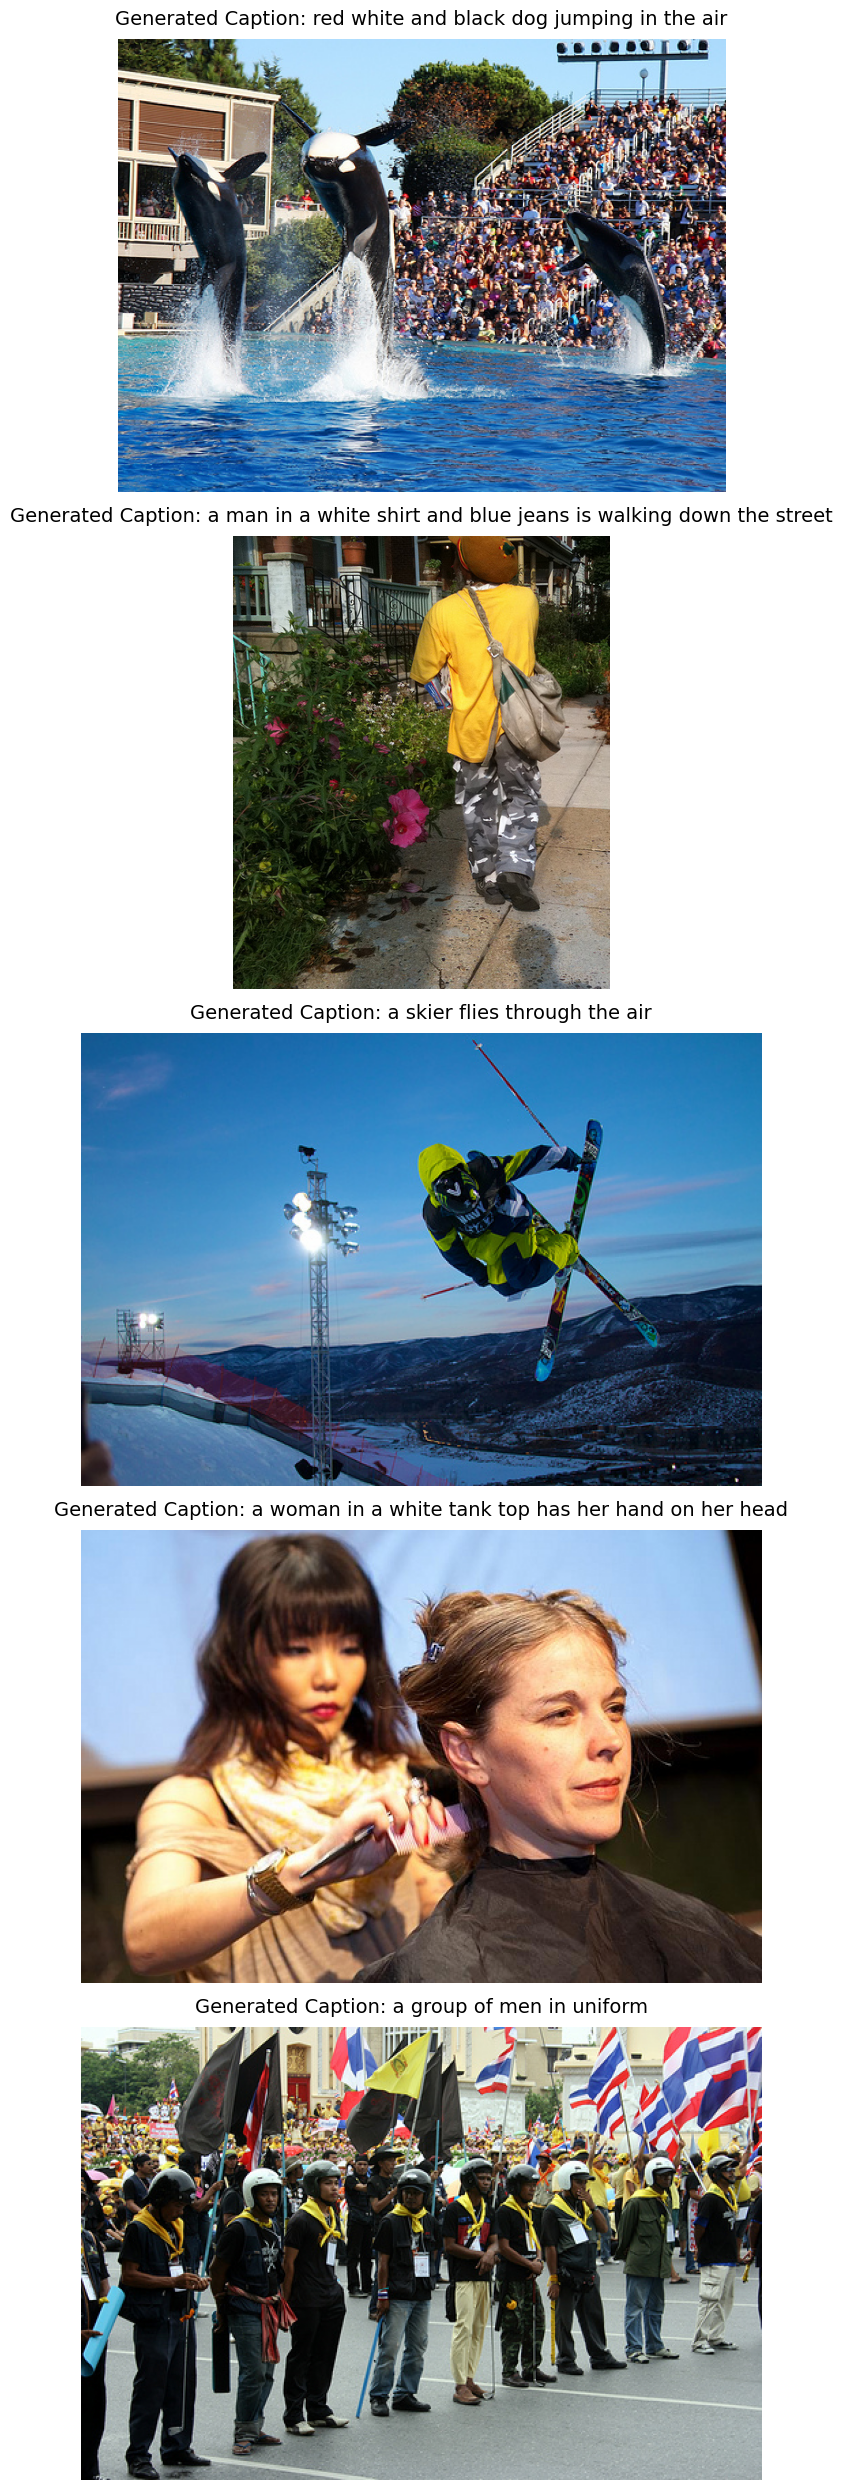

In [13]:
import random
import matplotlib.pyplot as plt
from PIL import Image
import os

# 1. Load the best weights once
checkpoint_path = 'best_flickr30k_model.pth'
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

# 2. Set up the plot (5 rows, 1 column)
num_samples = 5
plt.figure(figsize=(12, 25)) 

# 3. Loop to pick and predict 5 random images
for i in range(num_samples):
    # Pick a random index
    idx = random.randint(0, len(full_dataset)-1)
    feature, _ = full_dataset[idx] 
    image_name = full_dataset.image_names[idx] 

    # Generate the caption
    with torch.no_grad():
        # Pass 2048-D feature through Encoder
        encoded_feature = model.encoder(feature.unsqueeze(0).to(device))
        # Generate caption using Beam Search
        prediction = beam_search(model, encoded_feature.squeeze(0), vocab, beam_width=5)

    # 4. Display the result
    img_path = os.path.join(IMAGE_DIR, image_name)
    img = Image.open(img_path).convert("RGB")
    
    plt.subplot(num_samples, 1, i + 1)
    plt.imshow(img)
    plt.title(f"Generated Caption: {prediction}", fontsize=14, pad=10)
    plt.axis('off')
    
    print(f"Image {i+1}: {prediction}")

plt.tight_layout()
plt.show()